In [ ]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('playground-series-s6e4')

print("Path to competition files:", path)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import lightgbm as lgb 
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['axes.unicode_minus']=False
plt.rcParams['font.sans-serif']=['SimHei']
rand_seed = 67


In [3]:
df = pd.read_csv("C:\\Users\\赵一儒\\.cache\\kagglehub\\competitions\\playground-series-s6e4\\train.csv",encoding='utf-8')
print(f'数据集形状：{df.shape}')
print(f'列名：{df.columns.tolist()}')
print(df.head())
print(f"描述性统计：\n{df.describe(include='all')}")

数据集形状：(630000, 21)
列名：['id', 'Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare', 'Mulching_Used', 'Previous_Irrigation_mm', 'Region', 'Irrigation_Need']
   id Soil_Type  Soil_pH  Soil_Moisture  Organic_Carbon  \
0   0     Loamy     4.92          32.58            1.01   
1   1      Clay     7.08          56.61            0.44   
2   2      Clay     5.69          27.71            0.81   
3   3     Sandy     5.65          13.32            1.33   
4   4      Clay     7.96          59.14            0.38   

   Electrical_Conductivity  Temperature_C  Humidity  Rainfall_mm  \
0                     3.05          15.01     50.61       725.99   
1                     2.00          22.92     67.86       985.66   
2                     2.83          26.97     92.22      2201.70   
3    

目标变量分布：
 Irrigation_Need
Low       369917
Medium    239074
High       21009
Name: count, dtype: int64


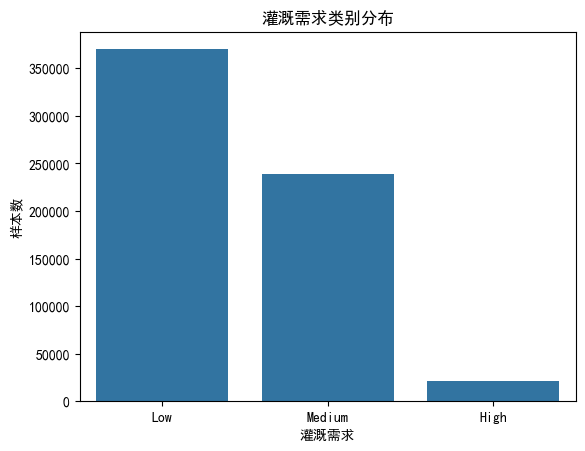

In [4]:
target_counts = df['Irrigation_Need'].value_counts()
print("目标变量分布：\n",target_counts)
sns.countplot(x='Irrigation_Need', data=df, order=['Low', 'Medium', 'High'])
plt.title('灌溉需求类别分布')
plt.xlabel('灌溉需求')
plt.ylabel('样本数')
plt.show()


数值型特征: ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']


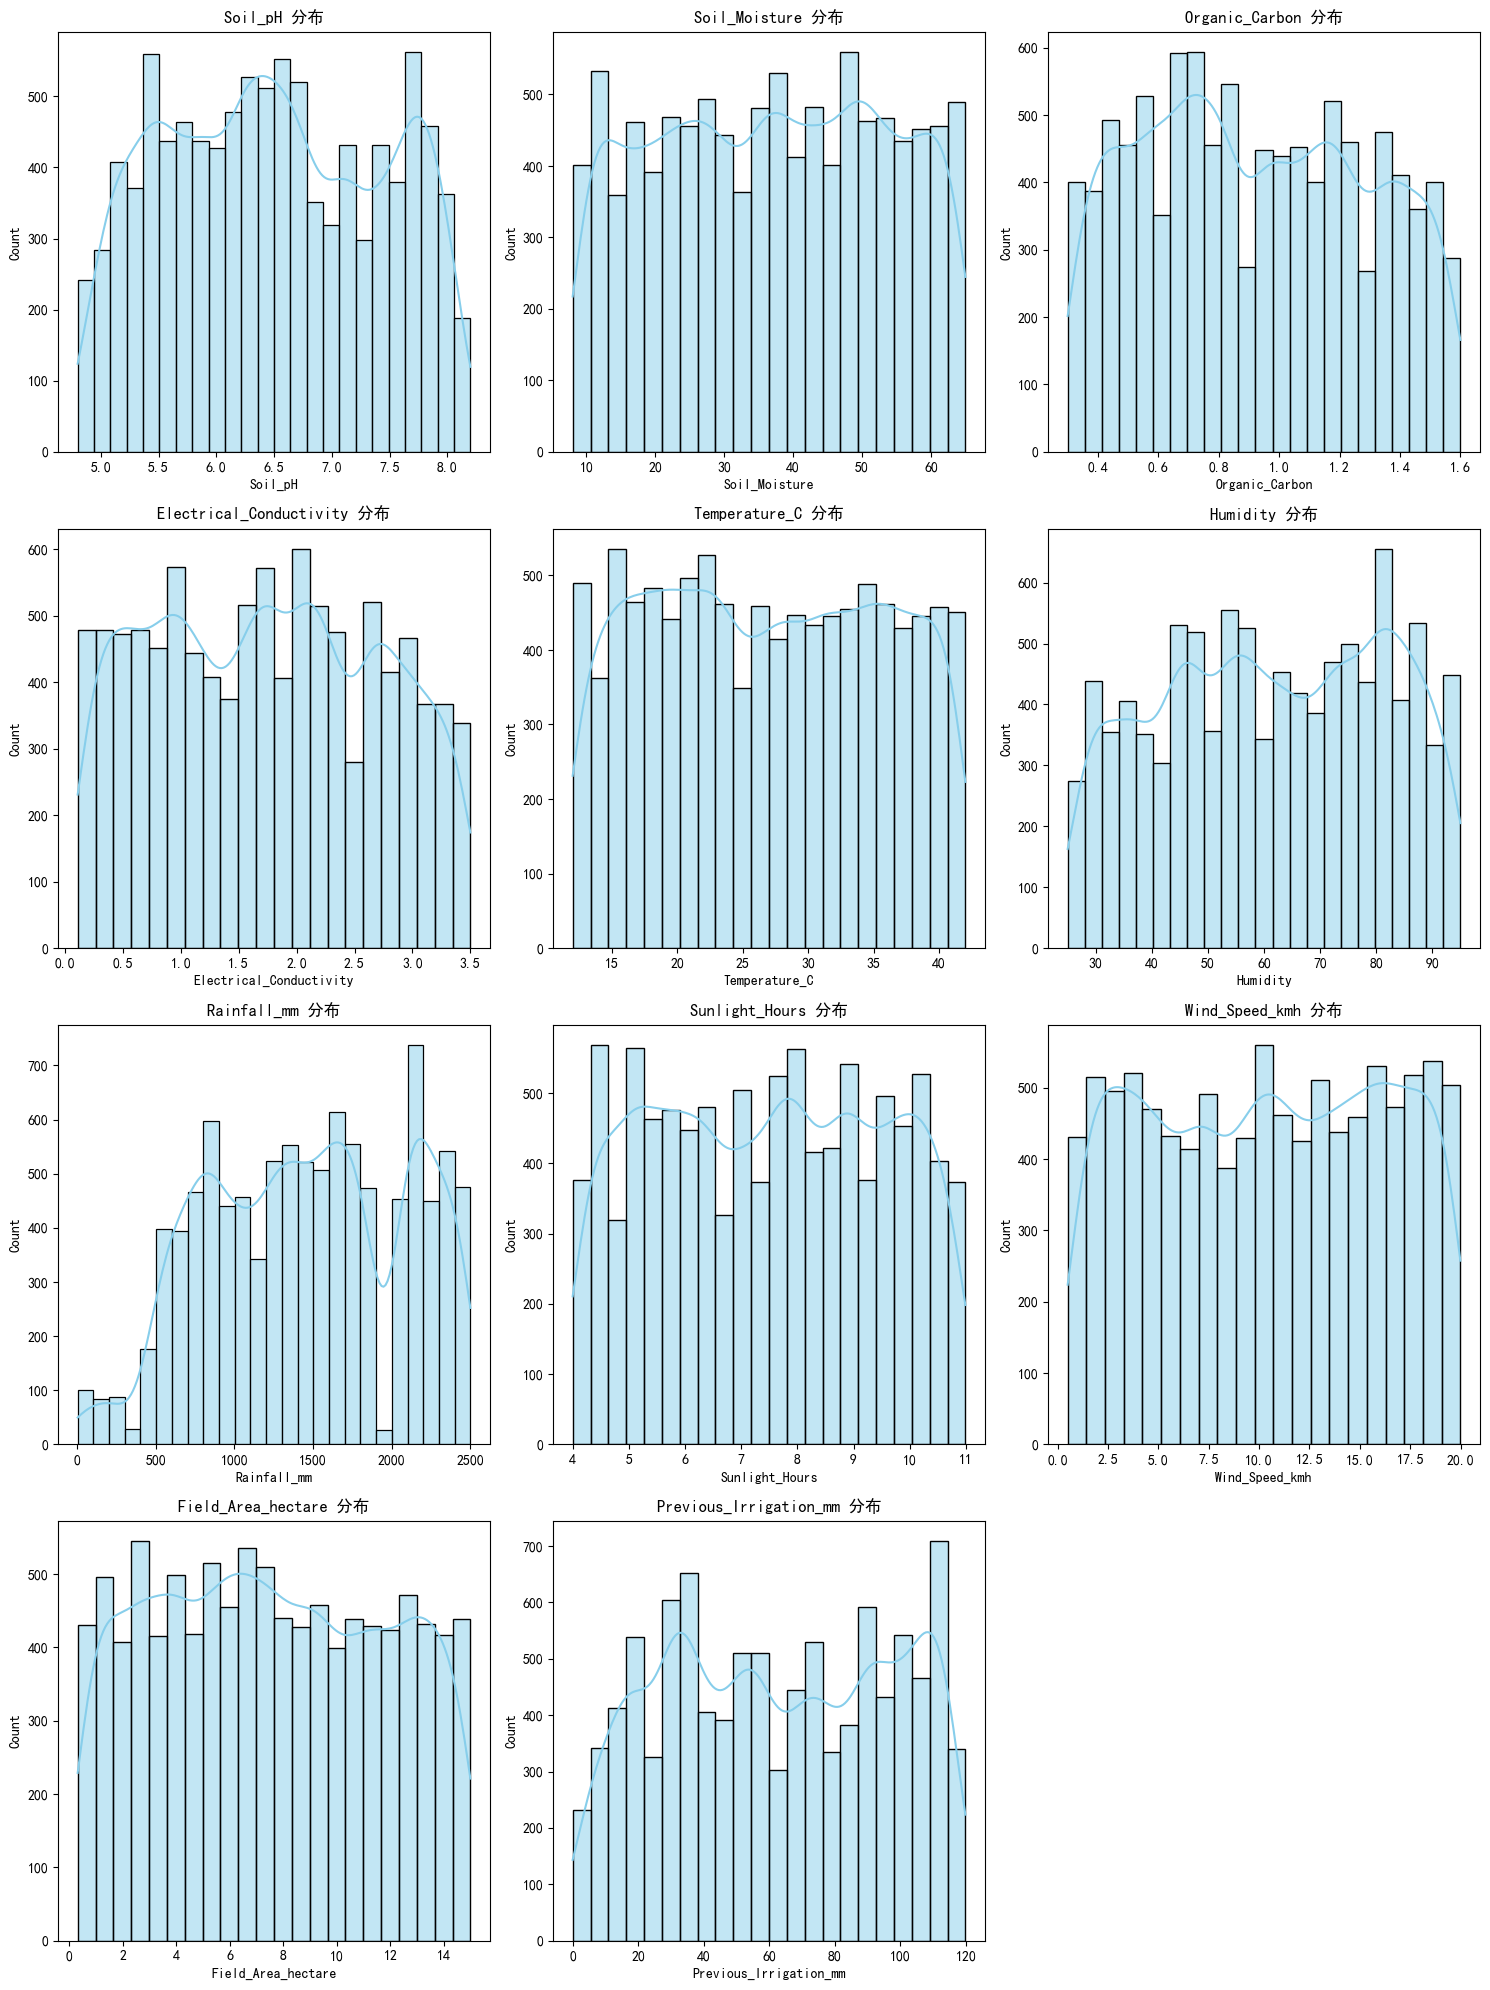

In [5]:
num_features = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
# 移除id列
if 'id' in num_features:
    num_features.remove('id')
print(f"\n数值型特征: {num_features}")

sample_df = df.sample(n=min(10000, len(df)), random_state=rand_seed)

# 绘制数值特征的分布直方图
n_cols = 3
n_rows = (len(num_features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten()
for i, col in enumerate(num_features):
    sns.histplot(sample_df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'{col} 分布')
    axes[i].set_xlabel(col)
# 隐藏多余的子图
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()


分类型特征: ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']


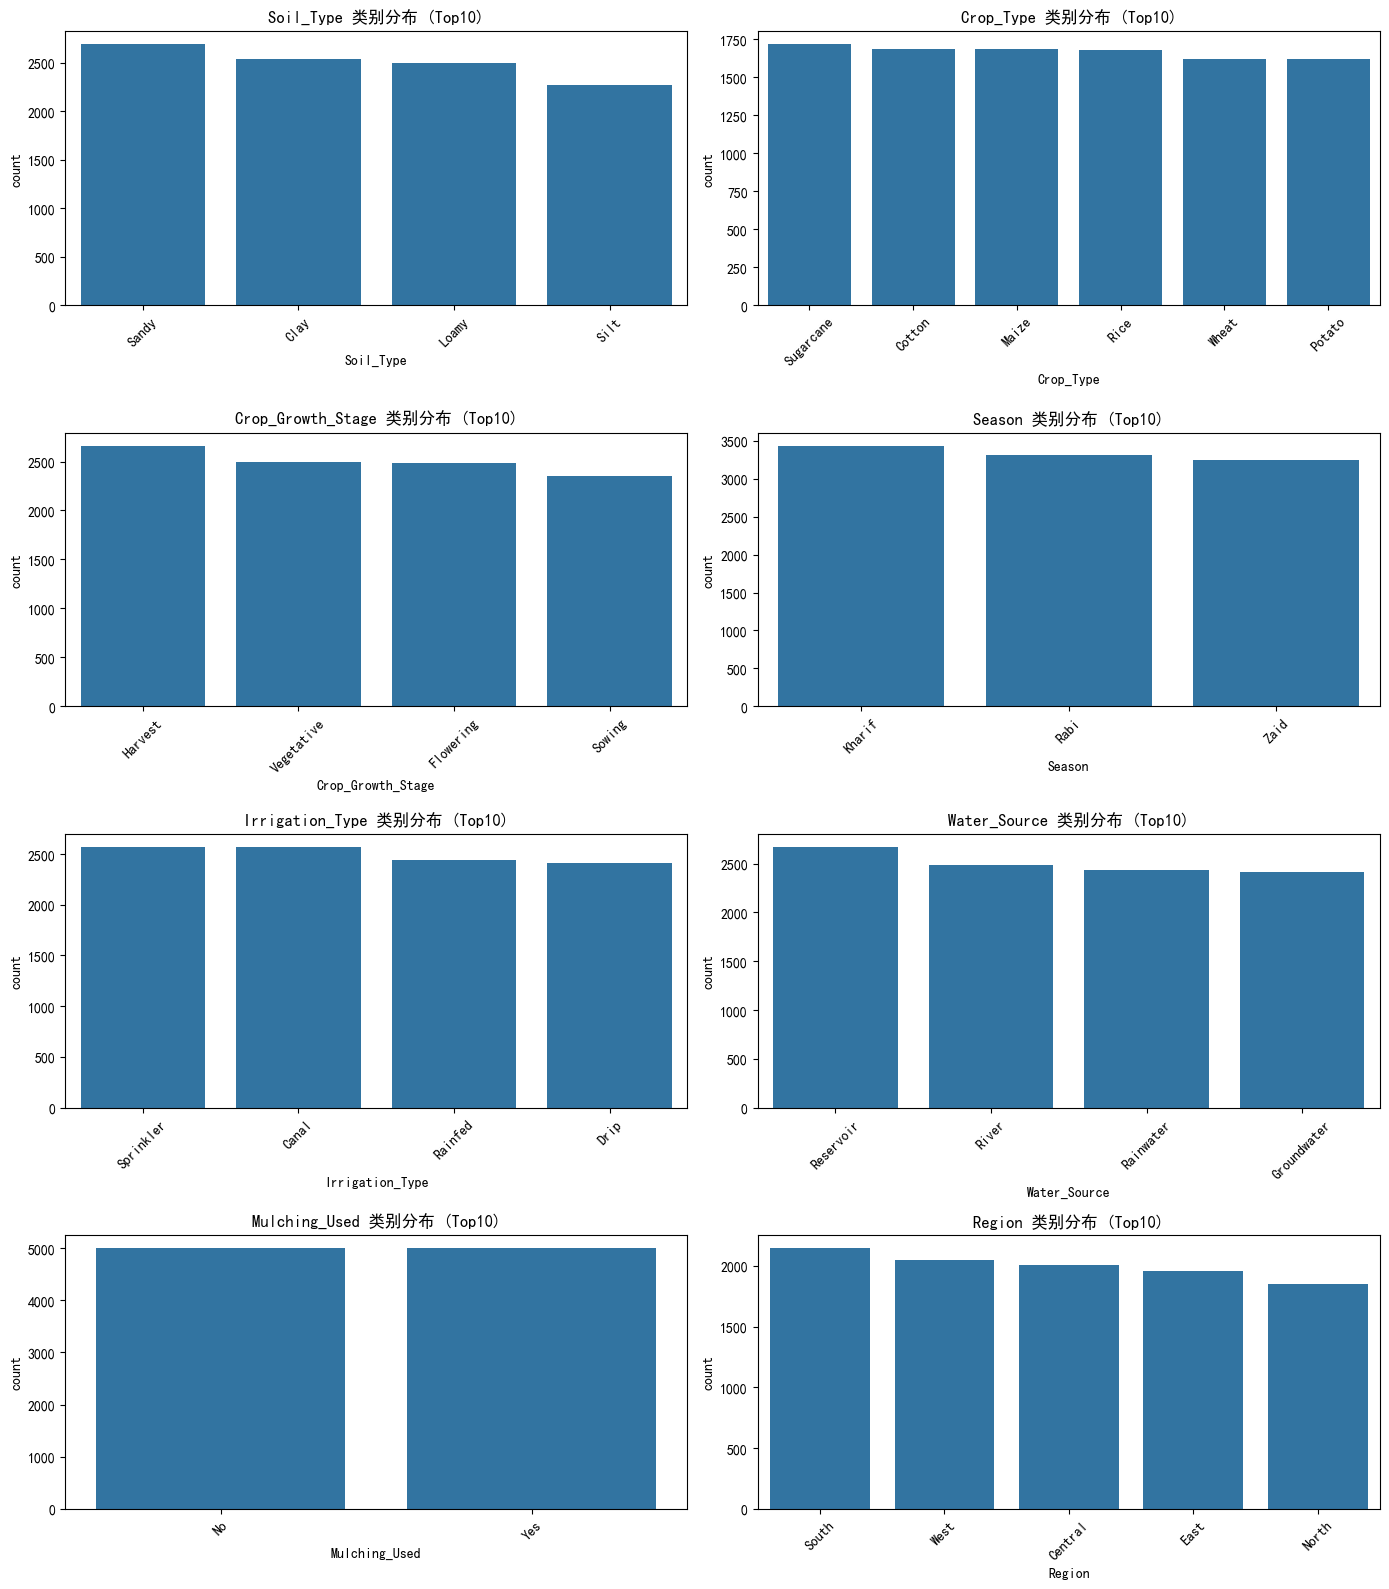

In [6]:
# 特征分布
cat_features = df.select_dtypes(include=['object']).columns.tolist()
cat_features = [c for c in cat_features if c != 'Irrigation_Need']  # 排除目标
print(f"\n分类型特征: {cat_features}")

if cat_features:
    n_cols = 2
    n_rows = (len(cat_features) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4*n_rows))
    if n_rows == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    for i, col in enumerate(cat_features):
        # 取前10个最频繁的类别（避免类别过多）
        top_categories = sample_df[col].value_counts().head(10).index
        sns.countplot(x=col, data=sample_df[sample_df[col].isin(top_categories)], 
                      order=top_categories, ax=axes[i])
        axes[i].set_title(f'{col} 类别分布 (Top10)')
        axes[i].set_xlabel(col)
        axes[i].tick_params(axis='x', rotation=45)
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout()
    plt.show()

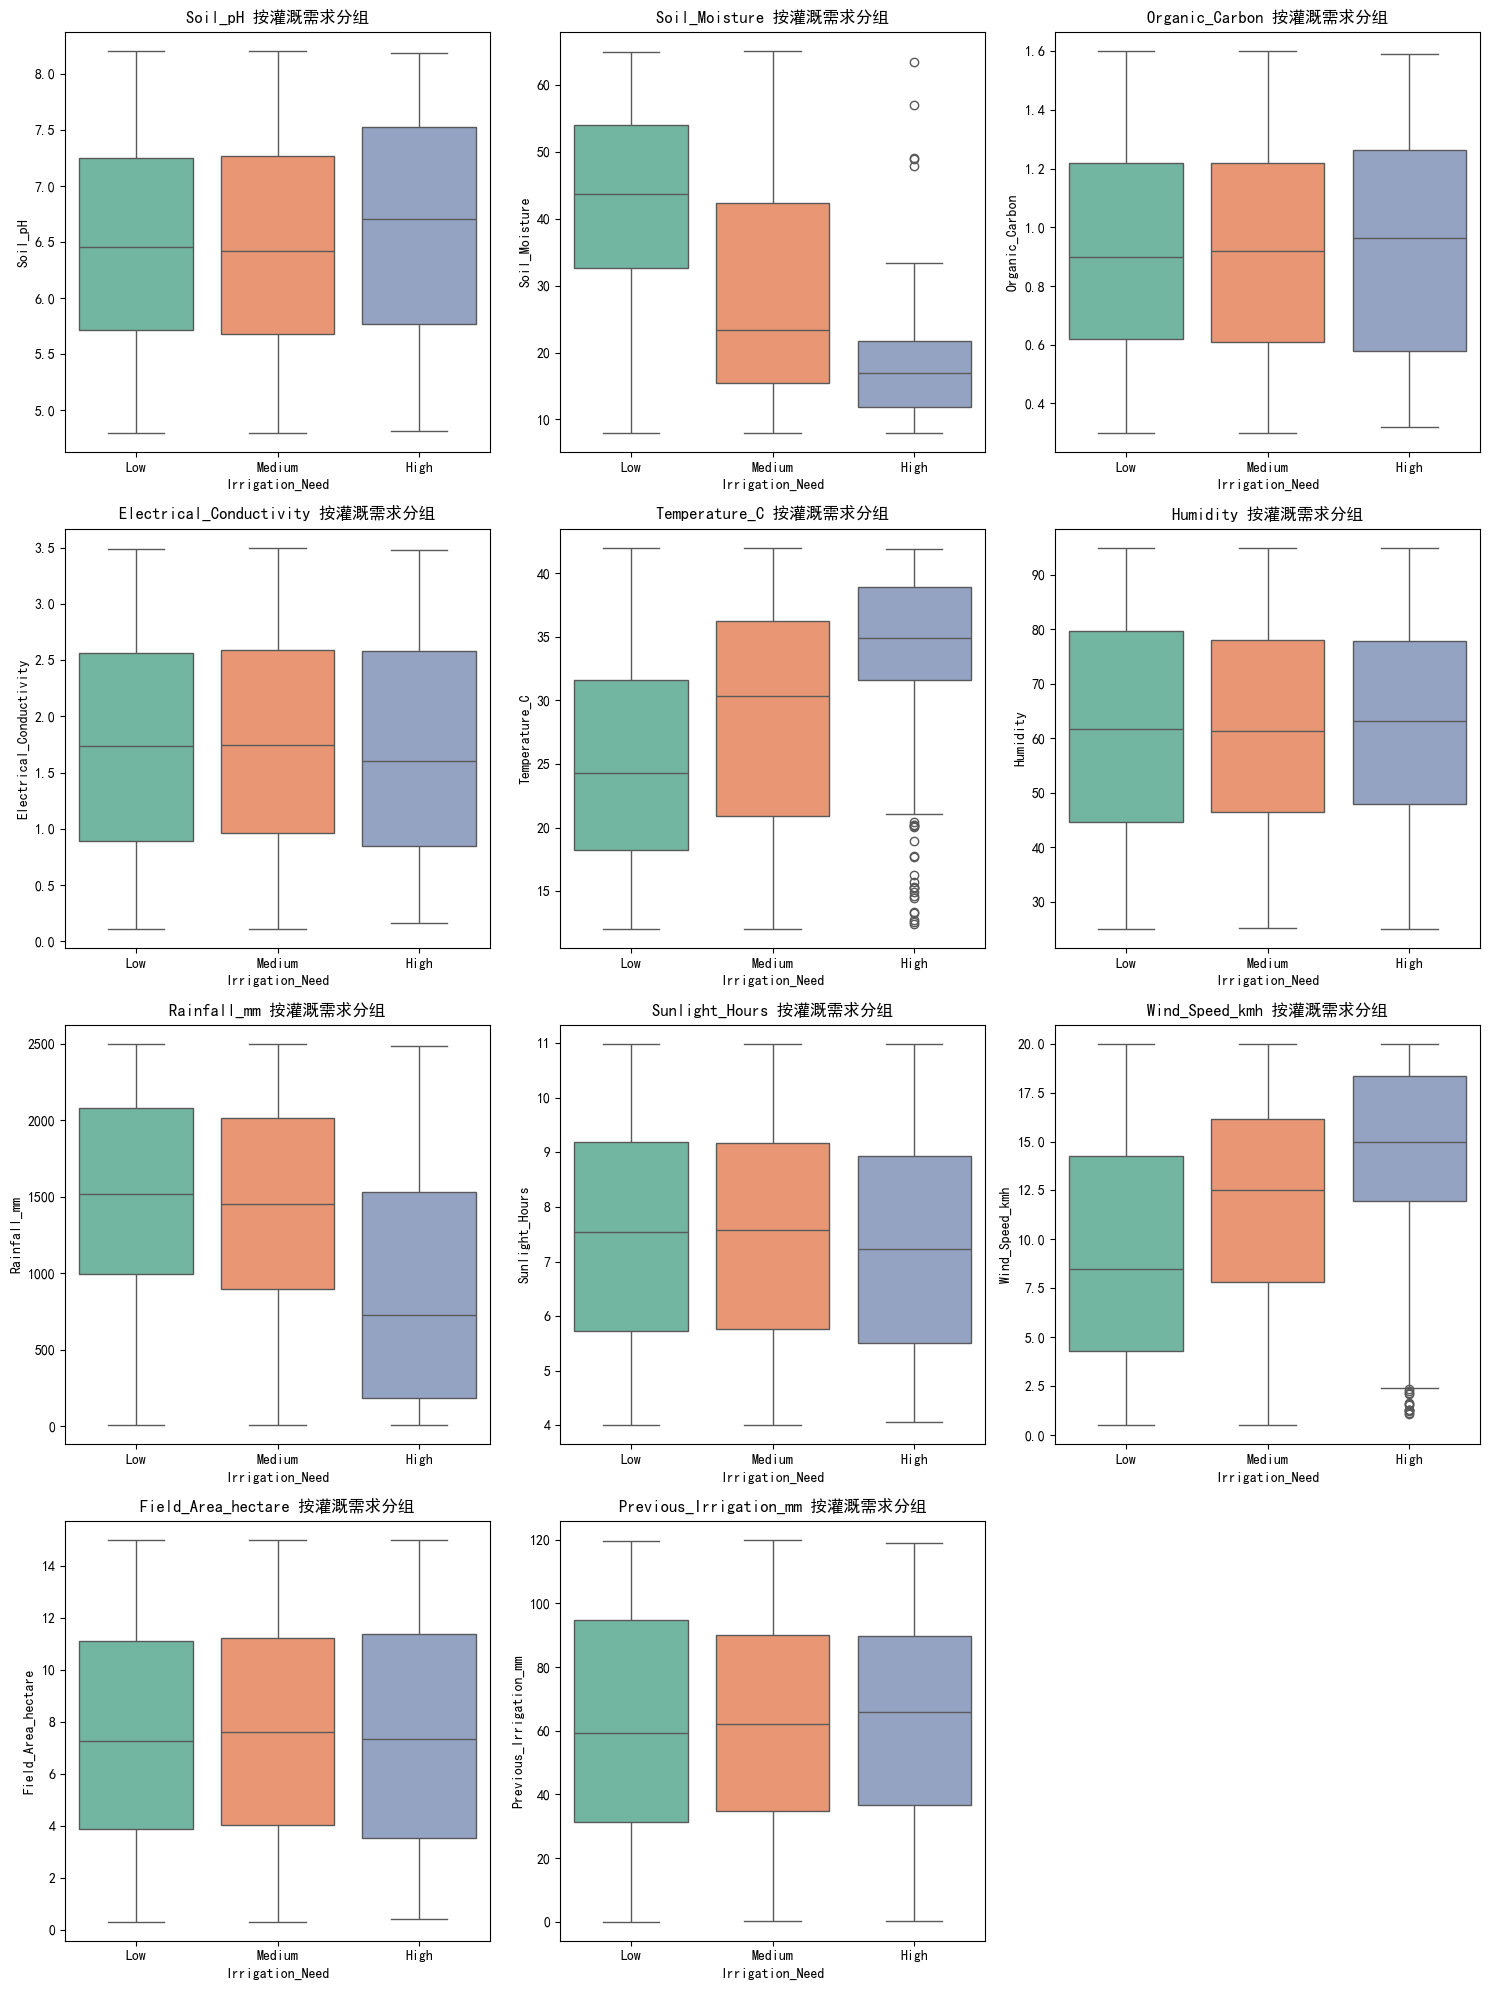

In [7]:
# 绘制数值特征按灌溉需求分组的箱线图
n_cols = 3
n_rows = (len(num_features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten()
for i, col in enumerate(num_features):
    sns.boxplot(x='Irrigation_Need', y=col, data=sample_df, 
                order=['Low', 'Medium', 'High'], ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} 按灌溉需求分组')
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

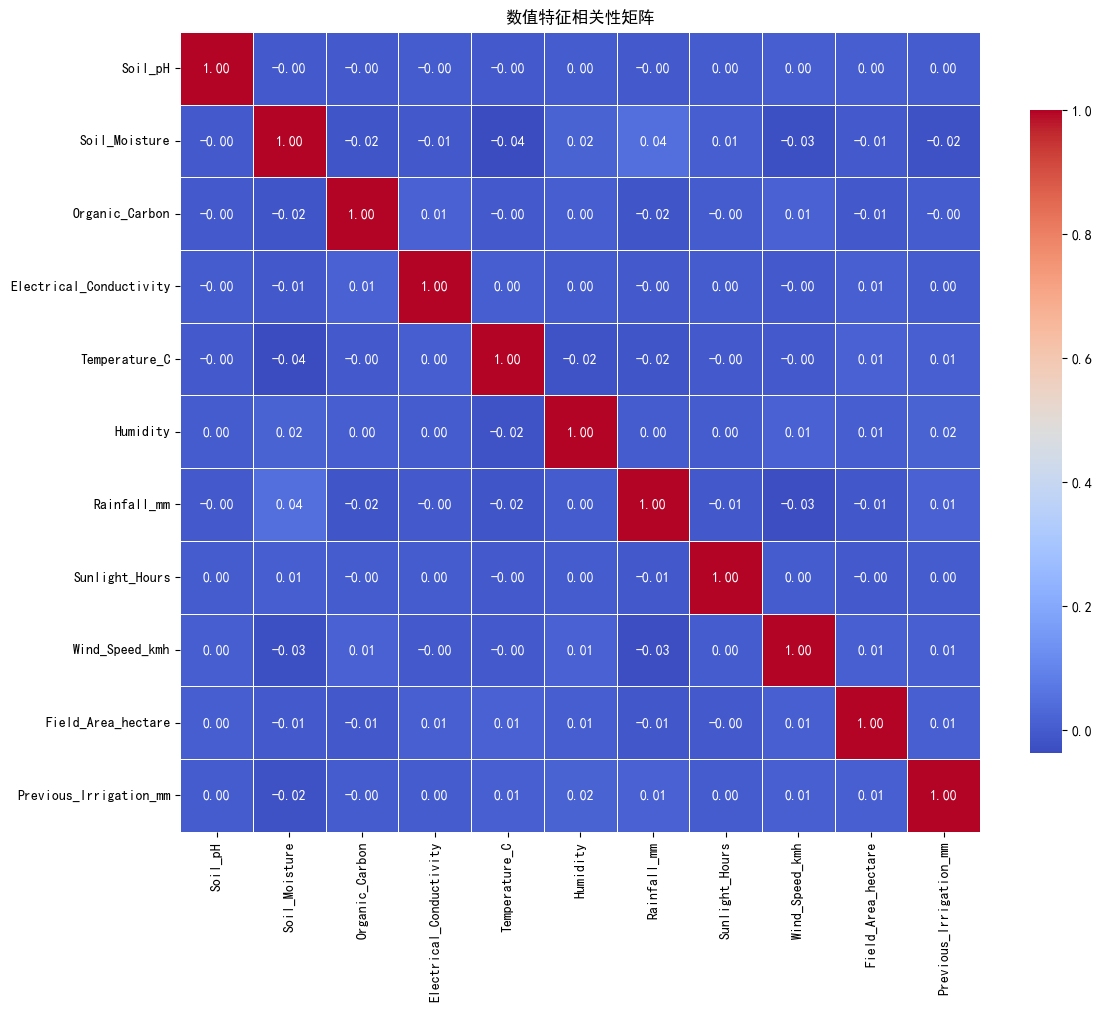

In [8]:
# 数值型特征之间的相关系数
corr_matrix = df[num_features].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('数值特征相关性矩阵')
plt.tight_layout()
plt.show()

In [9]:
# display(df.head())
df = df.drop(columns='id')
y = df['Irrigation_Need']
X = df.drop(columns='Irrigation_Need')

In [10]:

target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

num_features = X.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_features = X.select_dtypes(include=['object']).columns.tolist()
print(f"数值型特征 ({len(num_features)}): {num_features}")
print(f"分类型特征 ({len(cat_features)}): {cat_features}")

ordinal_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_cat_encoded = ordinal_encoder.fit_transform(X[cat_features])
X_cat_encoded = pd.DataFrame(X_cat_encoded, columns=cat_features, index=X.index)

scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X[num_features])
X_num_scaled = pd.DataFrame(X_num_scaled, columns=num_features, index=X.index)

X_final = pd.concat([X_num_scaled, X_cat_encoded], axis=1)
feature_names = num_features + cat_features
print(f"最终特征数: {X_final.shape[1]}")


数值型特征 (11): ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']
分类型特征 (8): ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']
最终特征数: 19


In [11]:
X_train, X_val, y_train, y_val = train_test_split(
    X_final, y_encoded, test_size=0.2, random_state=rand_seed, stratify=y_encoded
)
print(f"训练集大小: {X_train.shape}, 验证集大小: {X_val.shape}")

训练集大小: (504000, 19), 验证集大小: (126000, 19)


In [12]:
lgb_model = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=3,
    boosting_type='gbdt',
    n_estimators=750,
    learning_rate=0.05,
    num_leaves=33,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=rand_seed,
    n_jobs=-1,
    verbose=-1
)
eval_set = [(X_train, y_train), (X_val, y_val)]
lgb_model.fit(
    X_train, y_train,
    eval_set=eval_set,
    eval_metric='multi_logloss',
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)
print(lgb_model)

LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, n_estimators=750,
               n_jobs=-1, num_class=3, num_leaves=33, objective='multiclass',
               random_state=67, reg_alpha=0.1, reg_lambda=0.1, subsample=0.8,
               verbose=-1)


In [13]:
y_pred = lgb_model.predict(X_val)
acc = accuracy_score(y_val, y_pred)
print(f"\nLightGBM 验证集准确率: {acc:.4f}")
print("\n分类报告:\n", classification_report(y_val, y_pred, target_names=['Low', 'Medium', 'High']))
print("混淆矩阵:\n", confusion_matrix(y_val, y_pred))

importances = lgb_model.feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
print("\nTop 10 最重要的原始特征:\n", feat_imp.head(10))


LightGBM 验证集准确率: 0.9846

分类报告:
               precision    recall  f1-score   support

         Low       0.96      0.91      0.94      4202
      Medium       0.99      1.00      0.99     73983
        High       0.98      0.98      0.98     47815

    accuracy                           0.98    126000
   macro avg       0.98      0.96      0.97    126000
weighted avg       0.98      0.98      0.98    126000

混淆矩阵:
 [[ 3822     0   380]
 [    0 73614   369]
 [  144  1049 46622]]

Top 10 最重要的原始特征:
 Rainfall_mm                8692
Temperature_C              7151
Soil_Moisture              6875
Wind_Speed_kmh             6239
Previous_Irrigation_mm     5706
Humidity                   5685
Sunlight_Hours             4401
Soil_pH                    4279
Field_Area_hectare         4219
Electrical_Conductivity    4138
dtype: int32
